# ABM Crime Propensity Modeling with XGBoost

This notebook now works off the revised **station-hour** modeling dataset.

The key changes are:

- the target is no longer a probability multiplier
- the model learns a **log crime rate per estimated agent**
- the dataset includes **zero-crime station-hours**
- ABM-ready outputs are converted back into:
  - expected crimes for a station-hour
  - probability of at least one crime in that station-hour

In [78]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor, plot_importance

In [79]:
# File paths
MODELING_FILE = "model/modeling_dataset_hourly.csv"
BASELINE_FILE = "model/baseline_station_day_hour_probabilities.csv"

df = pd.read_csv(MODELING_FILE)
baseline = pd.read_csv(BASELINE_FILE)

print("Modeling dataset shape:", df.shape)
print("Baseline dataset shape:", baseline.shape)
df.head()

Modeling dataset shape: (639744, 56)
Baseline dataset shape: (576, 14)


,nearest_station,date_only,hour,day_type,is_weekend,hour_sin,hour_cos,month,day,dayofweek,...,smoothed_crime_count,smoothed_agents,target_rate,target_multiplier,target_log_multiplier,target_log_rate,observed_rate_per_agent,crime_occurred,baseline_prob_clipped,baseline_logit
0,3rd St/Convention,2017-01-01,0,Sunday,1,0.000000,1.000000,1,1,6,...,0.5,13.611134,0,0.0,-0.033516,-3.304035,0.0,0,0.033509,-3.361852
1,3rd St/Convention,2017-01-01,1,Sunday,1,0.258819,0.965926,1,1,6,...,0.5,14.529142,0,0.0,-0.035912,-3.369304,0.0,0,0.035904,-3.290338
2,3rd St/Convention,2017-01-01,2,Sunday,1,0.500000,0.866025,1,1,6,...,0.5,16.411058,0,0.0,-0.040807,-3.491103,0.0,0,0.040795,-3.157539
3,3rd St/Convention,2017-01-01,3,Sunday,1,0.707107,0.707107,1,1,6,...,0.5,8.596516,0,0.0,-0.020323,-2.844504,0.0,0,0.020321,-3.875550
4,3rd St/Convention,2017-01-01,4,Sunday,1,0.866025,0.500000,1,1,6,...,0.5,5.349063,0,0.0,-0.011685,-2.370069,0.0,0,0.011685,-4.437679


## Initial checks

These checks make sure the target and core features are present and inspect missing values before modeling.

In [80]:
# Parse dates
df["date_only"] = pd.to_datetime(df["date_only"], errors="coerce")

print(df.dtypes.sort_index())
print("\nMissing values by column:")
display(df.isna().sum().sort_values(ascending=False).head(25))

print("\nZero-crime share:")
print((df["crime_count"] == 0).mean())

print("\nTarget summary (target_log_rate):")
display(df["target_log_rate"].describe())

print("\nObserved rate per agent summary:")
if "observed_rate_per_agent" in df.columns:
    display(df["observed_rate_per_agent"].describe())

baseline_expected_count                    float64
baseline_logit                             float64
baseline_prob                              float64
baseline_prob_clipped                      float64
baseline_rate_per_agent                    float64
cloudcover                                 float64
crime_count                                  int64
crime_occurred                               int64
crime_share_within_day_type                float64
date_only                           datetime64[us]
day                                          int64
day_type                                       str
dayofweek                                    int64
env_within_10m                             float64
env_within_25m                             float64
env_within_50m                             float64
estimated_agents                           float64
estimated_station_agents                   float64
hour                                         int64
hour_cos                       

nearest_station        0
date_only              0
hour                   0
day_type               0
is_weekend             0
hour_sin               0
hour_cos               0
month                  0
day                    0
dayofweek              0
year_num               0
crime_count            0
temp                   0
tempmax                0
tempmin                0
precip                 0
precipcover            0
cloudcover             0
humidity               0
windspeed              0
visibility             0
snow                   0
nearest_tree_dist_m    0
trees_within_10m       0
trees_within_25m       0
dtype: int64


Zero-crime share:
0.9492046818727491

Target summary (target_log_rate):


count    639744.000000
mean         -3.879019
std           0.786861
min          -5.769837
25%          -4.397765
50%          -3.877966
75%          -3.391869
max          -0.545985
Name: target_log_rate, dtype: float64


Observed rate per agent summary:


count    639744.000000
mean          0.001905
std           0.011584
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           0.629144
Name: observed_rate_per_agent, dtype: float64

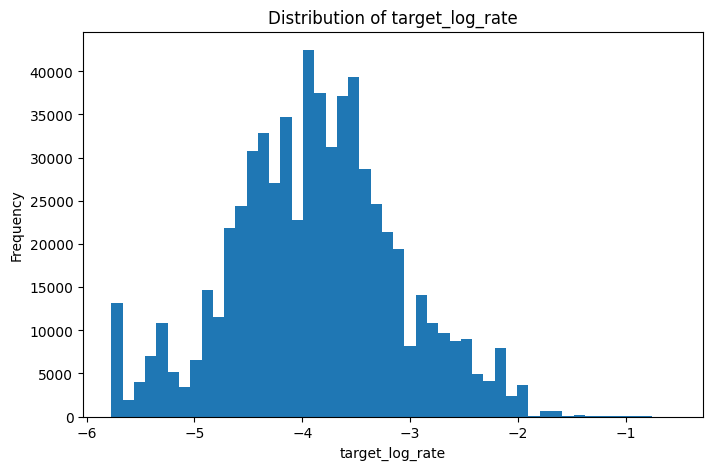

In [81]:
# Distribution of the main regression target
plt.figure(figsize=(8, 5))
plt.hist(df["target_log_rate"].dropna(), bins=50)
plt.xlabel("target_log_rate")
plt.ylabel("Frequency")
plt.title("Distribution of target_log_rate")
plt.show()

## Additional preparation for modeling

The revised preprocessing script creates a full **station × date × hour** panel, so the model now sees both:

- station-hours where crime happened
- station-hours where crime did not happen

That is important because the old crime-only training set inflated the learned probabilities.

The new target is:

\[
\text{target\_log\_rate} = \log(\text{smoothed crime count}) - \log(\text{smoothed estimated agents})
\]

So the model is learning a **rate per estimated agent**, not a raw event probability.

In [82]:
# Remove rows with missing target or date
df = df.dropna(subset=["target_log_rate", "date_only"]).copy()

# Extra time features
df["month"] = df["date_only"].dt.month
df["day"] = df["date_only"].dt.day
df["dayofweek"] = df["date_only"].dt.dayofweek
df["year_num"] = df["date_only"].dt.year

# Standardize string categorical columns
for col in ["day_type", "nearest_station"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Keep only valid rows for modeling / back-conversion
df = df[df["estimated_agents"].fillna(0) >= 0].copy()

print("Rows after dropping missing target/date:", len(df))
print("Zero-crime share after filtering:", (df["crime_count"] == 0).mean())

Rows after dropping missing target/date: 639744
Zero-crime share after filtering: 0.9492046818727491


## Leakage control

The model should learn **relative risk**, not simply memorize the baseline or the final answer.

Because the target is already normalized by estimated agents, we also exclude direct exposure and baseline outcome columns from the feature sets used for XGBoost.

In [83]:
target_col = "target_log_rate"

leakage_cols = [
    "target_log_rate",
    "target_log_multiplier",
    "target_multiplier",
    "target_rate",
    "crime_count",
    "crime_occurred",
    "baseline_expected_count",
    "baseline_prob",
    "baseline_logit",
    "baseline_rate_per_agent",
    "observed_rate_per_agent",
    "estimated_agents",
    "estimated_station_agents",
    "smoothed_crime_count",
    "smoothed_agents",
]

id_or_nonpredictive_cols = [
    "date_only",
]

# Environmental + temporal context
context_features = [
    "hour", "month",
    "temp", "tempmax", "tempmin", "precip", "precipcover", "cloudcover",
    "humidity", "windspeed", "visibility", "snow",
    "nearest_tree_dist_m", "trees_within_10m", "trees_within_25m", "trees_within_50m",
    "env_within_10m", "env_within_25m", "env_within_50m",
    "min_station_dist_m", "mean_station_dist_m", "num_stations_in_radius_from_list", "day_type"
]

# Adds station identity and ridership context
location_features = context_features + [
    "nearest_station",
    "ridership_share_within_day_type",
    "crime_share_within_day_type",
    "station_day_share",
    "hour_share",
]

# Smaller faster feature set
fast_features = [
    "hour", "dayofweek",
    "temp", "precip", "cloudcover", "humidity", "windspeed",
    "trees_within_50m", "env_within_50m",
    "min_station_dist_m", "nearest_station", "day_type",
    "station_overall_ridership", "ridership"
]

# Keep only columns that actually exist and are not leakage columns
context_features = [c for c in context_features if c in df.columns and c not in leakage_cols]
location_features = [c for c in location_features if c in df.columns and c not in leakage_cols]
fast_features = [c for c in fast_features if c in df.columns and c not in leakage_cols]

print("Context feature count:", len(context_features))
print("Location feature count:", len(location_features))
print("Fast feature count:", len(fast_features))

Context feature count: 23
Location feature count: 28
Fast feature count: 14


In [84]:
# Time-based split: train on earlier dates, test on later dates
split_date = df["date_only"].quantile(0.80)
train_df = df[df["date_only"] <= split_date].copy()
test_df = df[df["date_only"] > split_date].copy()

print("Split date:", split_date.date())
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train zero-crime share:", (train_df["crime_count"] == 0).mean())
print("Test zero-crime share:", (test_df["crime_count"] == 0).mean())

Split date: 2024-04-19
Train rows: 511872
Test rows: 127872
Train zero-crime share: 0.951526944236059
Test zero-crime share: 0.9399086586586587


## Modeling helper functions

In [85]:
def build_preprocessor(feature_list, frame):
    numeric_features = [c for c in feature_list if pd.api.types.is_numeric_dtype(frame[c])]
    categorical_features = [c for c in feature_list if c not in numeric_features]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), categorical_features),
        ],
        remainder="drop"
    )
    return preprocessor, numeric_features, categorical_features


def evaluate_regression(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        "model": label,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }


def back_convert_predictions(scored_df):
    out = scored_df.copy()
    out["pred_rate_per_agent"] = np.exp(out["pred_log_rate"])
    out["pred_smoothed_count"] = out["pred_rate_per_agent"] * (out["estimated_agents"] + 1.0)
    out["pred_expected_count"] = np.clip(out["pred_smoothed_count"] - 0.5, 0, None)
    out["pred_event_prob"] = 1 - np.exp(-out["pred_expected_count"])
    return out


def fit_xgb_model(train_df, test_df, feature_list, params, label):
    preprocessor, num_cols, cat_cols = build_preprocessor(feature_list, train_df)

    X_train = train_df[feature_list]
    y_train = train_df[target_col]
    X_test = test_df[feature_list]
    y_test = test_df[target_col]

    X_train_t = preprocessor.fit_transform(X_train)
    X_test_t = preprocessor.transform(X_test)

    model = XGBRegressor(**params)
    model.fit(X_train_t, y_train)

    preds = model.predict(X_test_t)

    metrics = evaluate_regression(y_test, preds, label)

    scored = test_df.copy()
    scored["pred_log_rate"] = preds
    scored = back_convert_predictions(scored)

    count_rmse = np.sqrt(mean_squared_error(scored["crime_count"], scored["pred_expected_count"]))
    count_mae = mean_absolute_error(scored["crime_count"], scored["pred_expected_count"])

    metrics["expected_count_rmse"] = count_rmse
    metrics["expected_count_mae"] = count_mae
    metrics["mean_pred_event_prob"] = scored["pred_event_prob"].mean()
    metrics["mean_baseline_prob"] = scored["baseline_prob"].mean()

    return {
        "label": label,
        "model": model,
        "preprocessor": preprocessor,
        "X_train_t": X_train_t,
        "X_test_t": X_test_t,
        "y_train": y_train,
        "y_test": y_test,
        "preds": preds,
        "metrics": metrics,
        "numeric_cols": num_cols,
        "categorical_cols": cat_cols,
        "features": feature_list,
        "scored_test": scored,
    }

## Fit and compare XGBoost models

The primary comparison metric is still RMSE on `target_log_rate`, but the table also includes:

- RMSE on **predicted expected crime count**
- MAE on **predicted expected crime count**
- the mean predicted event probability on the test set

Those extra metrics make it easier to judge whether the model behaves reasonably for the ABM.

In [86]:
common_params = dict(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

context_params = common_params.copy()

location_params = common_params.copy()
location_params.update({
    "max_depth": 7,
    "n_estimators": 400,
})

fast_params = common_params.copy()
fast_params.update({
    "n_estimators": 150,
    "max_depth": 5,
    "learning_rate": 0.08,
    "min_child_weight": 5,
})

In [87]:
context_result = fit_xgb_model(
    train_df=train_df,
    test_df=test_df,
    feature_list=context_features,
    params=context_params,
    label="XGB Contextual"
)

location_result = fit_xgb_model(
    train_df=train_df,
    test_df=test_df,
    feature_list=location_features,
    params=location_params,
    label="XGB Context + Location"
)

fast_result = fit_xgb_model(
    train_df=train_df,
    test_df=test_df,
    feature_list=fast_features,
    params=fast_params,
    label="XGB Fast/Shallow"
)

results_df = pd.DataFrame([
    context_result["metrics"],
    location_result["metrics"],
    fast_result["metrics"],
]).sort_values("rmse")

results_df

,model,rmse,mae,r2,expected_count_rmse,expected_count_mae,mean_pred_event_prob,mean_baseline_prob
1,XGB Context + Location,0.249110,0.107166,0.900685,0.245182,0.084742,0.035449,0.051906
2,XGB Fast/Shallow,0.249905,0.110640,0.900050,0.246326,0.085890,0.035567,0.051906
0,XGB Contextual,0.251529,0.110880,0.898746,0.245745,0.086352,0.037386,0.051906


Lower RMSE and MAE are better. Higher R² is better.

For ABM purposes, also pay attention to:

- `expected_count_rmse`
- `expected_count_mae`
- `mean_pred_event_prob`

If `mean_pred_event_prob` is dramatically larger than the baseline or the observed station-hour event rate, that is a warning sign that the model is still too aggressive.

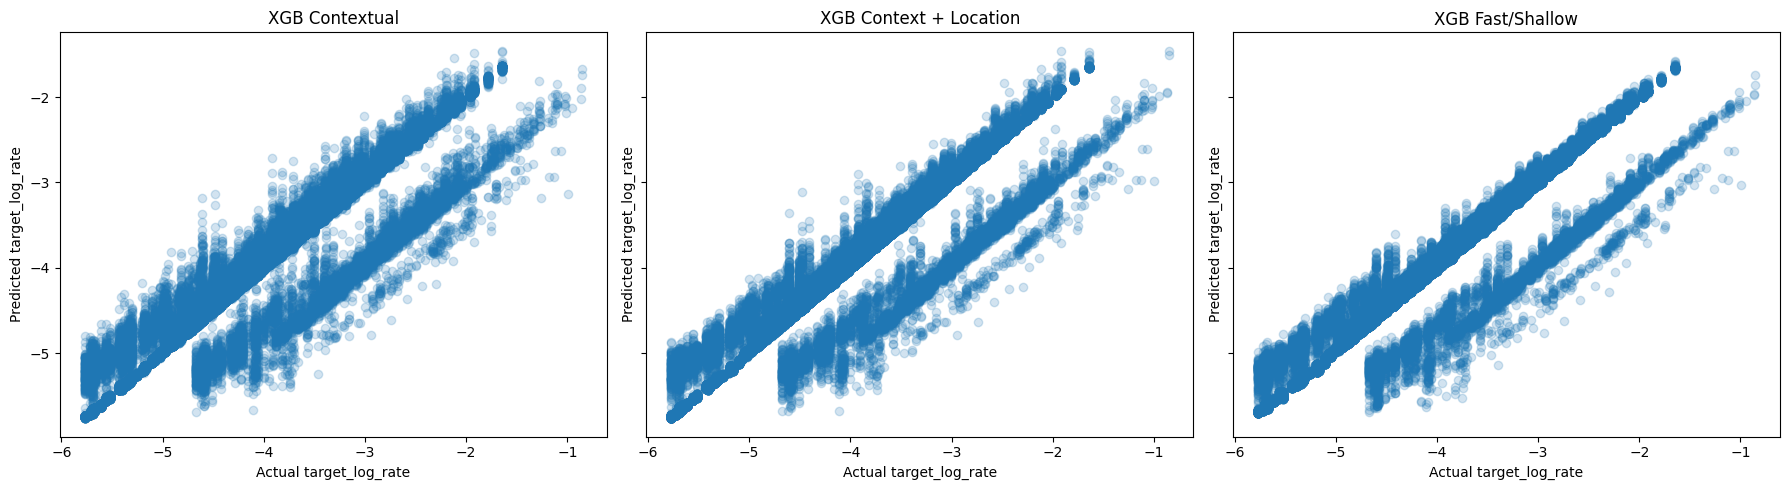

In [88]:
# Compare actual vs predicted for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, result in zip(
    axes,
    [context_result, location_result, fast_result]
):
    ax.scatter(result["y_test"], result["preds"], alpha=0.20)
    ax.set_title(result["label"])
    ax.set_xlabel("Actual target_log_rate")
    ax.set_ylabel("Predicted target_log_rate")

plt.tight_layout()
plt.show()

## Feature importance

The transformed feature matrix includes one-hot encoded categorical columns, so the names shown here are pulled directly from the fitted preprocessor rather than from the original raw feature list.

In [89]:
best_label = results_df.iloc[0]["model"]

best_result = {
    context_result["label"]: context_result,
    location_result["label"]: location_result,
    fast_result["label"]: fast_result,
}[best_label]

print("Best model by RMSE:", best_label)

Best model by RMSE: XGB Context + Location


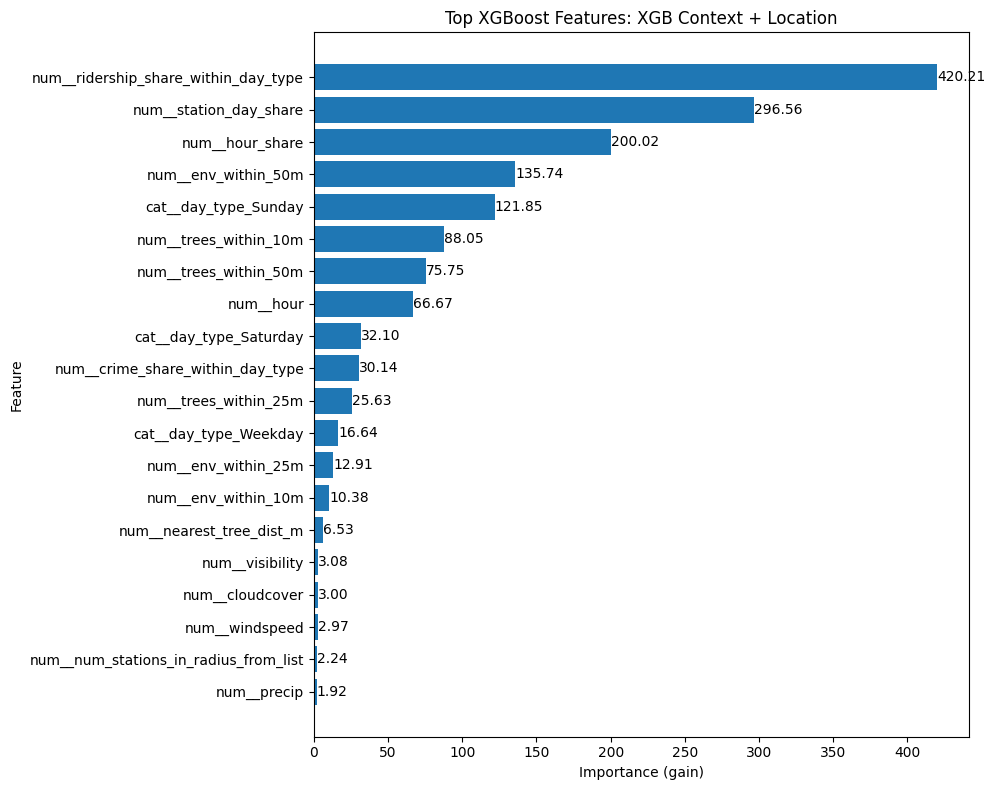

,xgb_name,importance_gain,feature_index,actual_name
22,f22,420.21,22,num__ridership_share_within_day_type
24,f24,296.56,24,num__station_day_share
25,f25,200.02,25,num__hour_share
18,f18,135.74,18,num__env_within_50m
27,f27,121.85,27,cat__day_type_Sunday
13,f13,88.05,13,num__trees_within_10m
15,f15,75.75,15,num__trees_within_50m
0,f0,66.67,0,num__hour
26,f26,32.10,26,cat__day_type_Saturday
23,f23,30.14,23,num__crime_share_within_day_type


In [90]:
feature_names = best_result["preprocessor"].get_feature_names_out()
booster_scores = best_result["model"].get_booster().get_score(importance_type="gain")

importance_df = pd.DataFrame({
    "xgb_name": list(booster_scores.keys()),
    "importance_gain": list(booster_scores.values())
})

# Round values
importance_df["importance_gain"] = importance_df["importance_gain"].round(2)

# Map to real feature names
importance_df["feature_index"] = importance_df["xgb_name"].str.replace("f", "", regex=False).astype(int)
importance_df["actual_name"] = importance_df["feature_index"].map(
    lambda i: feature_names[i] if i < len(feature_names) else f"unmapped_{i}"
)

# Sort and take top 20
importance_df = importance_df.sort_values("importance_gain", ascending=False).head(20)

# Plotting importance
plt.figure(figsize=(10, 8))

plt.barh(
    importance_df["actual_name"].iloc[::-1],
    importance_df["importance_gain"].iloc[::-1]
)

# Add rounded labels on bars
for i, v in enumerate(importance_df["importance_gain"].iloc[::-1]):
    plt.text(v, i, f"{v:.2f}", va="center")

plt.title(f"Top XGBoost Features: {best_label}")
plt.xlabel("Importance (gain)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

importance_df

In [91]:
importance_df.head(30)

,xgb_name,importance_gain,feature_index,actual_name
22,f22,420.21,22,num__ridership_share_within_day_type
24,f24,296.56,24,num__station_day_share
25,f25,200.02,25,num__hour_share
18,f18,135.74,18,num__env_within_50m
27,f27,121.85,27,cat__day_type_Sunday
13,f13,88.05,13,num__trees_within_10m
15,f15,75.75,15,num__trees_within_50m
0,f0,66.67,0,num__hour
26,f26,32.10,26,cat__day_type_Saturday
23,f23,30.14,23,num__crime_share_within_day_type


## Convert predictions into ABM-ready station-hour outputs

Because the model now predicts a **log rate per estimated agent**, the ABM conversion is:

1. exponentiate to recover the predicted rate per agent
2. multiply by estimated agents to get a station-hour expected count
3. convert that expected count into a station-hour event probability

\[
P(\text{at least one crime}) = 1 - e^{-\lambda}
\]

where \(\lambda\) is the predicted expected crime count for that station-hour.

In [92]:
# ABM-ready conversion on the test set for the best model
test_eval = best_result["scored_test"].copy()

test_eval[[
    "date_only", "hour", "nearest_station",
    "crime_count", "estimated_agents",
    "baseline_prob", "pred_log_rate",
    "pred_rate_per_agent", "pred_expected_count", "pred_event_prob"
]].head(10)

,date_only,hour,nearest_station,crime_count,estimated_agents,baseline_prob,pred_log_rate,pred_rate_per_agent,pred_expected_count,pred_event_prob
63984,2024-04-20,0,3rd St/Convention,0,20.276962,0.033154,-3.757575,0.023340,0.000000,0.000000
63985,2024-04-20,1,3rd St/Convention,0,21.752992,0.035524,-3.810220,0.022143,0.003827,0.003819
63986,2024-04-20,2,3rd St/Convention,0,24.778854,0.040364,-3.801363,0.022340,0.075908,0.073098
63987,2024-04-20,3,3rd St/Convention,0,12.214148,0.020104,-3.273318,0.037881,0.000559,0.000559
63988,2024-04-20,4,3rd St/Convention,0,6.992692,0.011560,-2.767984,0.062788,0.001849,0.001847
63989,2024-04-20,5,3rd St/Convention,0,5.608914,0.009283,-2.576891,0.076010,0.002343,0.002340
63990,2024-04-20,6,3rd St/Convention,0,11.051775,0.018209,-3.050360,0.047342,0.070553,0.068122
63991,2024-04-20,7,3rd St/Convention,0,27.472608,0.044653,-4.045183,0.017506,0.000000,0.000000
63992,2024-04-20,8,3rd St/Convention,0,30.867477,0.050030,-4.159142,0.015621,0.000000,0.000000
63993,2024-04-20,9,3rd St/Convention,0,36.660895,0.059137,-4.317350,0.013335,0.002214,0.002212


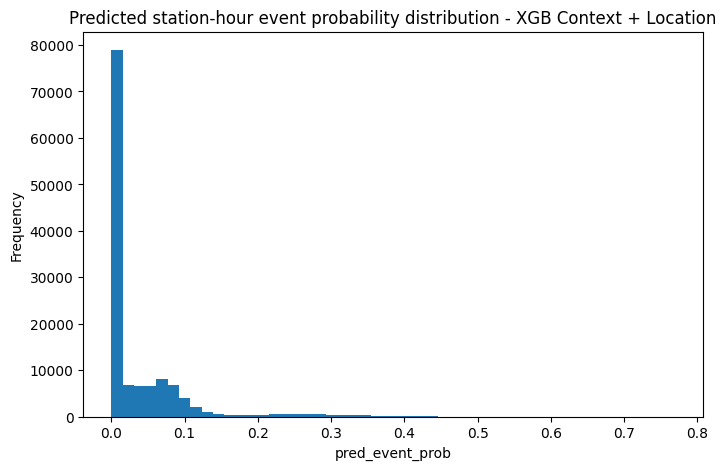

Observed station-hour event rate: 0.060091341341341344
Mean baseline station-hour probability: 0.051905557901487466
Mean predicted station-hour probability: 0.035449130327612544
Mean predicted expected count: 0.03855142139832018


In [93]:
plt.figure(figsize=(8, 5))
plt.hist(test_eval["pred_event_prob"], bins=50)
plt.xlabel("pred_event_prob")
plt.ylabel("Frequency")
plt.title(f"Predicted station-hour event probability distribution - {best_label}")
plt.show()

print("Observed station-hour event rate:", (test_eval["crime_count"] > 0).mean())
print("Mean baseline station-hour probability:", test_eval["baseline_prob"].mean())
print("Mean predicted station-hour probability:", test_eval["pred_event_prob"].mean())
print("Mean predicted expected count:", test_eval["pred_expected_count"].mean())

## Save the best fitted model inputs

The saved scored test set now contains station-hour expected counts and event probabilities that are directly usable in the ABM pipeline.

In [94]:
# results_df.to_csv("xgboost_model_comparison.csv", index=False)
# test_eval.to_csv("xgboost_scored_test_set.csv", index=False)

print("Saved: xgboost_model_comparison.csv")
print("Saved: xgboost_scored_test_set.csv")

Saved: xgboost_model_comparison.csv
Saved: xgboost_scored_test_set.csv


In [ ]:
import joblib
import os

# Pick correct model object
model_result = best_result

# Safety checks
assert "model" in model_result
assert "preprocessor" in model_result
assert "features" in model_result

print("Saving model:", model_result.get("label", "unknown"))
print("Number of features:", len(model_result["features"]))

# Build bundle
model_bundle = {
    "model": model_result["model"],
    "preprocessor": model_result["preprocessor"],
    "features": model_result["features"],
    "label": model_result.get("label", "xgb_context_location")
}

# Save
os.makedirs("model", exist_ok=True)
save_path = "model/xgb_context_location_bundle.joblib"

joblib.dump(model_bundle, save_path)

print(f"Model saved to: {save_path}")